# Matplotlib 核心绘图函数总结

本 Notebook 基于 `ZL_montecarlo.ipynb`、`ZL_FFT.ipynb`、`PartOne_HW.ipynb` 和 `Differential_Equation_HW.ipynb` 中的绘图实践，系统总结 `matplotlib.pyplot` 中最常用的绘图函数。

---
## 一、`plt.hist` — 绘制直方图

`plt.hist` 用于将一组数据按区间（bin）统计频次并绘制成柱状图，是观察数据分布形态的最直观工具。

### 核心参数

| 参数 | 说明 | 示例值 |
|:---|:---|:---|
| `x` | 输入数据，一维数组或列表 | `samples` |
| `bins` | 柱子的个数或边界序列 | `50`, `[0,1,2,5,10]` |
| `density` | 若为 `True`，纵轴显示概率密度而非计数 | `True` / `False` |
| `alpha` | 透明度，0~1，越大越不透明 | `0.6` |
| `color` | 柱子填充色 | `'g'`, `'steelblue'` |
| `label` | 图例文字 | `'Samples'` |
| `edgecolor` | 柱子边缘颜色 | `'white'` |


> **与 `plt.plot` / `plt.scatter` 的核心差异**：`plt.hist` 接收的是**原始样本数据**，内部自动完成分箱统计；而 `plot` 和 `scatter` 接收的是已经统计好的 `(x, y)` 坐标对。

### 示例：Metropolis-Hastings 采样结果的可视化

以下代码来自 `ZL_montecarlo.ipynb` 中 MH 算法的均匀提议分布版本，展示了如何用 `plt.hist` 对比采样分布与真实分布。

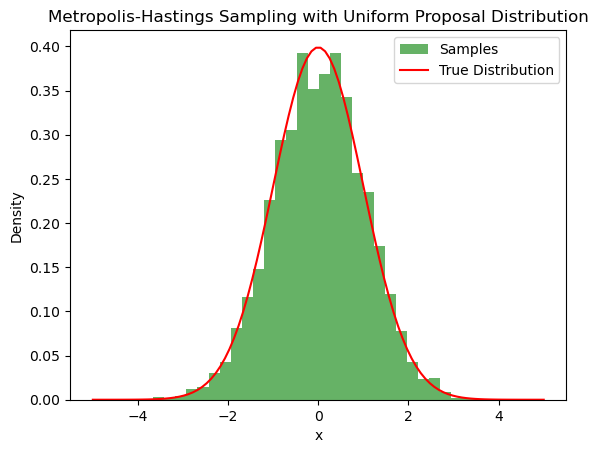

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 目标分布 p(x)，标准正态分布
def target_distribution(x):
    return np.exp(-0.5 * x**2)  # 标准正态分布的概率密度

# 提议分布 q(x'|x)，选择均匀分布 U(x_t - delta, x_t + delta)
def proposal_distribution(x, delta=1):
    return np.random.uniform(x - delta, x + delta)  # 从 x 出发，生成一个新的候选点

# Metropolis-Hastings算法
def metropolis_hastings(iterations, initial_state, delta=1):
    x = initial_state
    samples = [x]
    
    for _ in range(iterations):
        # 步骤2：从提议分布中抽样候选值 y
        y = proposal_distribution(x, delta)
        
        # 步骤3：计算接受概率 alpha
        alpha = min(1, target_distribution(y) / target_distribution(x))
        
        # 步骤4：生成随机数 u
        u = np.random.rand()
        
        # 步骤5：决策
        if u <= alpha:  # 如果 u <= alpha，接受 y
            x = y
        samples.append(x)  # 记录当前状态
    
    return np.array(samples)

# 运行Metropolis-Hastings算法
iterations = 10000
initial_state = 0  # 初始状态为0
delta = 5  # 提议分布的范围
samples = metropolis_hastings(iterations, initial_state, delta)

# 可视化结果
plt.hist(samples, bins=30, density=True, alpha=0.6, color='g', label='Samples')
x = np.linspace(-5, 5, 100)
plt.plot(x, np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi), 'r', label='True Distribution')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.title('Metropolis-Hastings Sampling with Uniform Proposal Distribution')
plt.show()

---
## 二、`plt.plot`、`plt.scatter` 与 `plt.imshow` 的对比

这三个函数是 Matplotlib 中最基础也最常用的绘图命令，但它们的**输入数据形式和适用场景**有明显区别。

### 函数对比表

| 函数 | 输入数据形式 | 核心用途 | 典型参数 |
|:---|:---|:---|:---|
| `plt.plot(x, y)` | `x`, `y` 均为**一维数组**（长度相同） | 绘制折线图/曲线 | `color`, `linestyle`, `linewidth`, `marker`, `label` |
| `plt.scatter(x, y)` | `x`, `y` 均为**一维数组**（长度相同） | 绘制散点图 | `s`（点大小）, `c`（颜色）, `alpha`, `marker` |
| `plt.imshow(X)` | `X` 为**二维数组** `(M, N)` 或 `(M, N, 3/4)` | 显示图像/热力图/矩阵 | `cmap`, `vmin`, `vmax`, `origin`, `aspect` |

### 关键差异详解

1. **`plt.plot` vs `plt.scatter`**
   - 两者都接收 `(x, y)` 坐标对，但 `plot` 默认用线段连接相邻点，适合展示**连续变化趋势**；
   - `scatter` 绘制的是独立点，适合展示**离散样本**或需要按点设置大小时（如 Monte Carlo 撒点图）。

2. **`plt.imshow` 的独特性**
   - `imshow` 接收的是**单个二维数组**，数组的每个元素直接映射为一种颜色；
   - 不需要显式提供 `x` 和 `y` 坐标，像素位置即数组索引；
   - 常用于显示：灰度图像、彩色图像、频谱幅度矩阵、热力图等。

### 示例：FFT 图像频谱分析（来自 `ZL_FFT.ipynb`）

下面的代码展示了 `plt.imshow` 在频域分析中的典型用法：将二维 FFT 变换后的幅度谱以图像形式可视化。

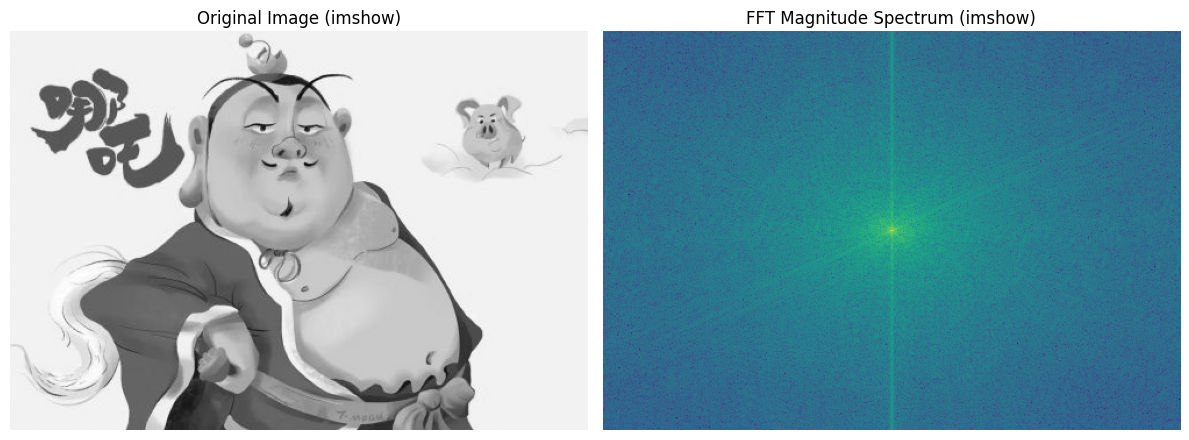

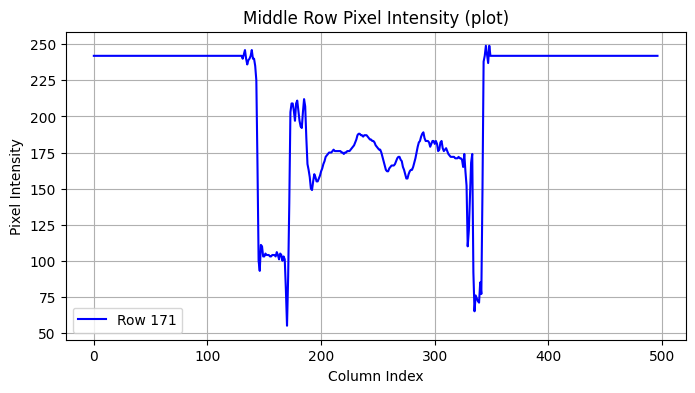

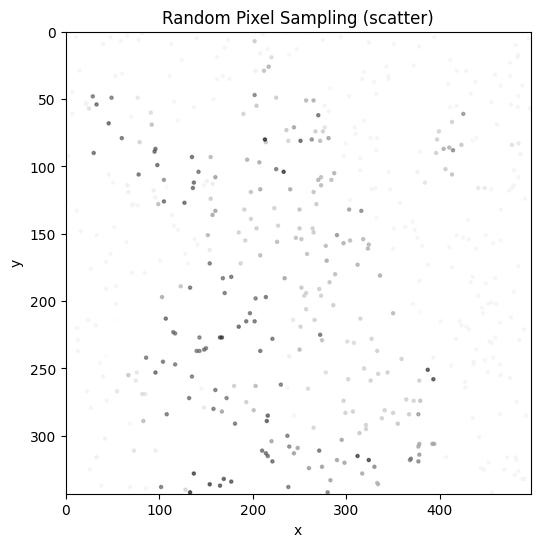

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# 读取图像
image = cv2.imread('sample.jpg', cv2.IMREAD_GRAYSCALE)  # 读取图像
if image is None:
    raise ValueError("图像加载失败，请检查文件路径！")


# 计算 2D 傅里叶变换（FFT）
f_transform = np.fft.fft2(image)
f_shifted = np.fft.fftshift(f_transform)  # 频谱中心化：将零频分量移到中心

# 计算幅度谱（取对数增强可视性）
magnitude_spectrum = np.log(np.abs(f_shifted) + 1)

# ========== 同时展示 plot / scatter / imshow 的用法差异 ==========

# 1) plt.imshow —— 显示二维矩阵（图像或频谱）
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')   # 输入：二维数组；cmap 控制颜色映射
plt.title("Original Image (imshow)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(magnitude_spectrum)   # 输入：二维数组；默认使用 viridis 颜色映射
plt.title("FFT Magnitude Spectrum (imshow)")
plt.axis('off')

plt.tight_layout()
plt.show()

# 2) plt.plot —— 绘制一维曲线（例如某一行像素强度）
plt.figure(figsize=(8, 4))
row_idx = image.shape[0] // 2
plt.plot(image[row_idx, :], label=f'Row {row_idx}', color='b')  # 输入：一维数组
plt.xlabel('Column Index')
plt.ylabel('Pixel Intensity')
plt.title('Middle Row Pixel Intensity (plot)')
plt.legend()
plt.grid(True)
plt.show()

# 3) plt.scatter —— 绘制离散点（例如随机采样部分像素）
plt.figure(figsize=(6, 6))
n_samples = 500
h, w = image.shape
x_rand = np.random.randint(0, w, n_samples)
y_rand = np.random.randint(0, h, n_samples)
colors = image[y_rand, x_rand]  # 用像素值作为颜色
plt.scatter(x_rand, y_rand, c=colors, cmap='gray', s=5, alpha=0.6)  # 输入：一维数组 x, y
plt.xlim(0, w)
plt.ylim(0, h)
plt.gca().invert_yaxis()
plt.title('Random Pixel Sampling (scatter)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

---
## 三、`plt.subplot` 布局、`figsize` 与 `plt.show()`

### 1. `plt.subplot` 的用法

`plt.subplot(nrows, ncols, index)` 用于将画布划分为 `nrows × ncols` 的网格，并激活第 `index` 个子图进行绘制。

- **经典写法**：`plt.subplot(2, 2, 1)` 表示 2 行 2 列的第 1 个子图（编号从左到右、从上到下）。
- **简化写法**：`plt.subplot(221)` 等价于 `plt.subplot(2, 2, 1)`，但当行列数 ≥10 时容易歧义，不推荐。
- **推荐使用 `plt.subplots()`**（注意多了个 `s`）：一次性创建 Figure 和所有 Axes，返回 `(fig, axes)`，更适合复杂布局。

### 2. `figsize` 的设置

`figsize` 控制整个图形的宽高（单位：英寸），格式为 `(width, height)`。

- 在 `plt.figure(figsize=(10, 6))` 中设置；
- 或在 `plt.subplots(2, 2, figsize=(10, 8))` 中统一设置；
- 宽 > 高 适合横向并排；高 > 宽 适合纵向堆叠。

### 3. `plt.show()` 什么时候用？

| 场景 | 是否需要 `plt.show()` | 说明 |
|:---|:---|:---|
| **脚本文件 `.py`** | ✅ 必须显式调用 | 脚本非交互运行，需要 `show()` 阻塞/打开图形窗口 |
| **Jupyter Notebook** | 可选 | 每个 Cell 末尾的输出会自动显示图形；一个 Cell 内绘制多张图时，可在最后统一 `show()` |
| **保存图片时** | 建议先 `show()` 或 `savefig()` | `savefig()` 应在 `show()` **之前**调用，否则可能保存空白图 |

> **注意**：在 Notebook 中，如果在一个 Cell 里绘制了多张独立的 `plt.figure()`，不调用 `show()` 也能正常显示；但加上 `show()` 可以让代码意图更清晰，且与脚本环境保持兼容。

### 综合示例：多子图布局

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 生成示例数据
t = np.linspace(0, 2 * np.pi, 200)
x = np.random.randn(300)

# ========== 方式一：plt.subplot 逐个添加 ==========
plt.figure(figsize=(12, 4))  # 宽 12 英寸，高 4 英寸

plt.subplot(1, 3, 1)
plt.plot(t, np.sin(t), 'b-', label='sin')
plt.plot(t, np.cos(t), 'r--', label='cos')
plt.title('plt.plot')
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(np.random.rand(50), np.random.rand(50), c='green', alpha=0.5)
plt.title('plt.scatter')

plt.subplot(1, 3, 3)
plt.hist(x, bins=30, color='orange', edgecolor='black')
plt.title('plt.hist')

plt.suptitle('Comparison of plot / scatter / hist', fontsize=14, y=1.02)
plt.tight_layout()  # 自动调整子图间距，防止重叠
plt.show()

# ========== 方式二：plt.subplots 推荐写法 ==========
fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # 2行2列，总尺寸 10×8 英寸

axes[0, 0].plot(t, np.sin(t))
axes[0, 0].set_title('Sine Wave')

axes[0, 1].scatter(t[::10], np.sin(t[::10]), c='red', s=30)
axes[0, 1].set_title('Sampled Points')

axes[1, 0].hist(np.random.randn(1000), bins=40, color='steelblue', edgecolor='white')
axes[1, 0].set_title('Normal Distribution')

# imshow 示例：绘制一个二维函数 z = sin(x) * cos(y)
x2 = np.linspace(0, 2*np.pi, 100)
y2 = np.linspace(0, 2*np.pi, 100)
X2, Y2 = np.meshgrid(x2, y2)
Z = np.sin(X2) * np.cos(Y2)
im = axes[1, 1].imshow(Z, cmap='viridis', origin='lower')
axes[1, 1].set_title('2D Function (imshow)')
fig.colorbar(im, ax=axes[1, 1])  # 为 imshow 添加颜色条

plt.suptitle('Multi-panel Figure using subplots()', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

---
## 小结

| 需求 | 推荐函数 | 输入数据特点 |
|:---|:---|:---|
| 展示数据分布 | `plt.hist` | 一维原始样本，自动分箱 |
| 绘制连续曲线 | `plt.plot` | 两个一维数组 `(x, y)` |
| 绘制离散点/撒点 | `plt.scatter` | 两个一维数组 `(x, y)`，可逐点控制样式 |
| 显示图像/矩阵/频谱 | `plt.imshow` | **单个二维数组**，元素值映射为颜色 |
| 多子图布局 | `plt.subplot` 或 `plt.subplots` | 通过网格索引或返回的 `axes` 对象管理 |

掌握这几个函数及其参数差异，就能覆盖科学计算中绝大多数的可视化需求。

### 补充一个jupyter notebook导出pdf的方法

执行完下面的cell之后用浏览器打开html，然后print出pdf即可。可以绕开pandoc+tex的pdf依赖

In [ ]:
!jupyter-nbconvert --to html filename.ipynb